In [ ]:
import os
import re

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
ABLATION_CONFIGS = {
    "epsilon": {
        "metrics_dir": "/lustre/groups/ml01/workspace/ot_perturbation/data/pbmc/metrics_new_donor_epsilon",
        "wandb_csv": "/lustre/groups/ml01/workspace/ot_perturbation/models/otfm/pbmc_new_donor_ablation_epsilon/wandb.csv",
    },
    "unbalancedness": {
        "metrics_dir": "/lustre/groups/ml01/workspace/ot_perturbation/data/pbmc/metrics_new_donor_unbalancedness",
        "wandb_csv": "/lustre/groups/ml01/workspace/ot_perturbation/models/otfm/pbmc_new_donor_ablation_unbalancedness/wandb.csv",
    },
    "batch_size": {
        "metrics_dir": "/lustre/groups/ml01/workspace/ot_perturbation/data/pbmc/metrics_new_donor_batch_size",
        "wandb_csv": "/lustre/groups/ml01/workspace/ot_perturbation/data/pbmc/metrics_new_donor_batch_size/wandb.csv",
    },
}
EXPECTED_N = 240

In [3]:
def load_and_process(ablation_type, metrics_dir, wandb_csv_path, expected_n=240):
    # Load all metrics CSV files
    files = [f for f in os.listdir(metrics_dir) if f.endswith("_metrics.csv")]
    dfs = []
    for f in files:
        dfs.append(pd.read_csv(os.path.join(metrics_dir, f), index_col=0).T)
    df = pd.concat(dfs)
    print(f"[{ablation_type}] Loaded {len(files)} files, {df.shape[0]} rows")

    # Map wandb_name -> idx_given_donor using wandb.csv
    wandb_csv = pd.read_csv(wandb_csv_path)
    name_to_idx = dict(
        zip(wandb_csv["Name"], wandb_csv["dataset.idx_given_donor"].astype(int))
    )
    df["idx_given_donor"] = df["wandb_name"].map(name_to_idx)
    df["cytokine"] = df.index
    df["run_number"] = df["wandb_name"].apply(
        lambda x: int(re.search(r"(\d+)$", x).group(1))
    )

    # Deduplicate: keep newest run per (ablation_value, idx_given_donor, cytokine)
    df = df.sort_values("run_number", ascending=False).drop_duplicates(
        subset=["ablation_value", "idx_given_donor", "cytokine"], keep="first"
    )
    print(f"[{ablation_type}] After dedup: {df.shape[0]} rows")

    # Ensure exactly expected_n per ablation_value:
    # Keep 3 complete seeds (10 cytokines each) per cytokine_in_train group.
    # 8 cytokine_in_train groups * 3 seeds * 10 cytokines = 240
    df["cytokine_in_train"] = pd.to_numeric(df["cytokine_in_train"])

    selected = []
    for abl_val, abl_group in df.groupby("ablation_value"):
        abl_selected = []
        for cit, cit_group in abl_group.groupby("cytokine_in_train"):
            seed_counts = cit_group.groupby("idx_given_donor")["cytokine"].count()
            complete_seeds = seed_counts[seed_counts == 10].index.tolist()
            if len(complete_seeds) >= 3:
                # Keep 3 most recent complete seeds
                recency = (
                    cit_group[cit_group["idx_given_donor"].isin(complete_seeds)]
                    .groupby("idx_given_donor")["run_number"]
                    .mean()
                    .nlargest(3)
                    .index
                )
                abl_selected.append(
                    cit_group[cit_group["idx_given_donor"].isin(recency)]
                )
            else:
                print(
                    f"  WARNING: ablation={abl_val}, cytokine_in_train={cit}: "
                    f"only {len(complete_seeds)} complete seeds (need 3)"
                )
                abl_selected.append(
                    cit_group[cit_group["idx_given_donor"].isin(complete_seeds)]
                )
        selected.append(pd.concat(abl_selected))

    df = pd.concat(selected)
    df = df.drop(columns=["idx_given_donor", "cytokine", "run_number"])

    # Cast key metric columns to float
    df["mean_decoded_r_sq_per_cell_type"] = df[
        "mean_decoded_r_sq_per_cell_type"
    ].astype(float)
    df["ood_e_distance"] = df["ood_e_distance"].astype(float)

    # Verify
    counts = df.groupby("ablation_value").size()
    print(f"[{ablation_type}] Final counts per ablation_value:")
    print(counts)
    assert (counts == expected_n).all(), (
        f"Not all ablation values have {expected_n} data points:\n"
        f"{counts[counts != expected_n]}"
    )
    print(f"[{ablation_type}] All ablation values have {expected_n} data points.")

    return df

In [4]:
dfs = {}
for ablation_type, config in ABLATION_CONFIGS.items():
    print(f"\n{'=' * 60}")
    print(f"Processing: {ablation_type}")
    print(f"{'=' * 60}")
    dfs[ablation_type] = load_and_process(
        ablation_type, config["metrics_dir"], config["wandb_csv"], EXPECTED_N
    )


Processing: epsilon
[epsilon] Loaded 1690 files, 1690 rows
[epsilon] After dedup: 1680 rows
[epsilon] Final counts per ablation_value:
ablation_value
0.001        240
0.01         240
0.1          240
1.0          240
10.0         240
100.0        240
1000000.0    240
dtype: int64
[epsilon] All ablation values have 240 data points.

Processing: unbalancedness
[unbalancedness] Loaded 1590 files, 1590 rows
[unbalancedness] After dedup: 1200 rows
[unbalancedness] Final counts per ablation_value:
ablation_value
0.8     240
0.9     240
0.95    240
0.99    240
1.0     240
dtype: int64
[unbalancedness] All ablation values have 240 data points.

Processing: batch_size
[batch_size] Loaded 2177 files, 2177 rows
[batch_size] After dedup: 2160 rows
[batch_size] Final counts per ablation_value:
ablation_value
1024    240
128     240
16      240
2048    240
256     240
32      240
4096    240
512     240
64      240
dtype: int64
[batch_size] All ablation values have 240 data points.


In [5]:
for ablation_type, df in dfs.items():
    print(f"\n{ablation_type}")
    print(f"  Shape: {df.shape}")
    print(f"  Ablation values: {sorted(df['ablation_value'].unique())}")
    ct = pd.crosstab(
        df["ablation_value"], df["cytokine_in_train"]
    )
    ct["total"] = ct.sum(axis=1)
    print(ct)


epsilon
  Shape: (1680, 53)
  Ablation values: ['0.001', '0.01', '0.1', '1.0', '10.0', '100.0', '1000000.0']
cytokine_in_train   2   3   5   9  17  33  65  81  total
ablation_value                                          
0.001              30  30  30  30  30  30  30  30    240
0.01               30  30  30  30  30  30  30  30    240
0.1                30  30  30  30  30  30  30  30    240
1.0                30  30  30  30  30  30  30  30    240
10.0               30  30  30  30  30  30  30  30    240
100.0              30  30  30  30  30  30  30  30    240
1000000.0          30  30  30  30  30  30  30  30    240

unbalancedness
  Shape: (1200, 53)
  Ablation values: ['0.8', '0.9', '0.95', '0.99', '1.0']
cytokine_in_train   2   3   5   9  17  33  65  81  total
ablation_value                                          
0.8                30  30  30  30  30  30  30  30    240
0.9                30  30  30  30  30  30  30  30    240
0.95               30  30  30  30  30  30  30  30    240

In [18]:
output_dir = "/lustre/groups/ml01/workspace/ot_perturbation/figures/pbmc/ablation_studies"

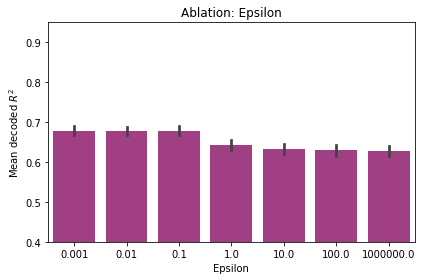

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

df_eps = dfs["epsilon"].copy()
df_eps["ablation_value"] = pd.to_numeric(df_eps["ablation_value"])
df_eps["mean_deg_r_sq_per_cell_type"] = pd.to_numeric(df_eps["mean_deg_r_sq_per_cell_type"])
df_eps = df_eps.sort_values("ablation_value")

fig, ax = plt.subplots()
sns.barplot(
    data=df_eps,
    x="ablation_value",
    y="mean_deg_r_sq_per_cell_type",
    color="#B12F8C",
    ax=ax,
)
ax.set_ylim(0.4, 0.95)
ax.set_xlabel("Epsilon")
ax.set_ylabel("Mean decoded $R^2$")
ax.set_title("Ablation: Epsilon")
plt.tight_layout()
plt.show()
fig.savefig(os.path.join(output_dir, "ablation_epsilon.pdf"), bbox_inches="tight")

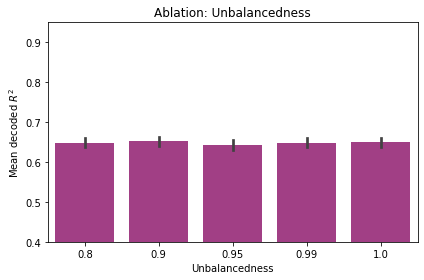

In [38]:
df_unb = dfs["unbalancedness"].copy()
df_unb["ablation_value"] = pd.to_numeric(df_unb["ablation_value"])
df_unb["mean_deg_r_sq_per_cell_type"] = pd.to_numeric(df_unb["mean_deg_r_sq_per_cell_type"])
df_unb = df_unb.sort_values("ablation_value")

fig, ax = plt.subplots()
sns.barplot(
    data=df_unb,
    x="ablation_value",
    y="mean_deg_r_sq_per_cell_type",
    color="#B12F8C",
    ax=ax,
)
ax.set_ylim(0.4, 0.95)
ax.set_xlabel("Unbalancedness")
ax.set_ylabel("Mean decoded $R^2$")
ax.set_title("Ablation: Unbalancedness")
plt.tight_layout()
plt.show()
fig.savefig(os.path.join(output_dir, "ablation_unbalancedness.pdf"), bbox_inches="tight")

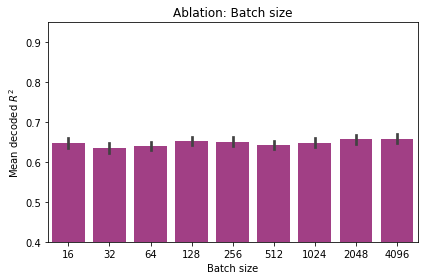

In [39]:
df_bs = dfs["batch_size"].copy()
df_bs["ablation_value"] = pd.to_numeric(df_bs["ablation_value"])
df_bs["mean_deg_r_sq_per_cell_type"] = pd.to_numeric(df_bs["mean_deg_r_sq_per_cell_type"])

df_bs = df_bs.sort_values("ablation_value")

fig, ax = plt.subplots()
sns.barplot(
    data=df_bs,
    x="ablation_value",
    y="mean_deg_r_sq_per_cell_type",
    color="#B12F8C",
    ax=ax,
)
ax.set_ylim(0.4, 0.95)
ax.set_xlabel("Batch size")
ax.set_ylabel("Mean decoded $R^2$")
ax.set_title("Ablation: Batch size")
plt.tight_layout()
plt.show()
fig.savefig(os.path.join(output_dir, "ablation_batch_size.pdf"), bbox_inches="tight")

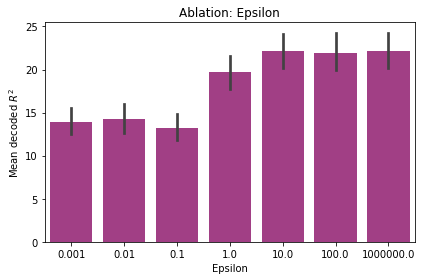

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

df_eps = dfs["epsilon"].copy()
df_eps["ablation_value"] = pd.to_numeric(df_eps["ablation_value"])
df_eps["ood_e_distance"] = pd.to_numeric(df_eps["ood_e_distance"])
df_eps = df_eps.sort_values("ablation_value")

fig, ax = plt.subplots()
sns.barplot(
    data=df_eps,
    x="ablation_value",
    y="ood_e_distance",
    color="#B12F8C",
    ax=ax,
)

ax.set_xlabel("Epsilon")
ax.set_ylabel("Energy distance")
ax.set_title("Ablation: Epsilon")
plt.tight_layout()
plt.show()
fig.savefig(os.path.join(output_dir, "ablation_epsilon_e_dist.pdf"), bbox_inches="tight")

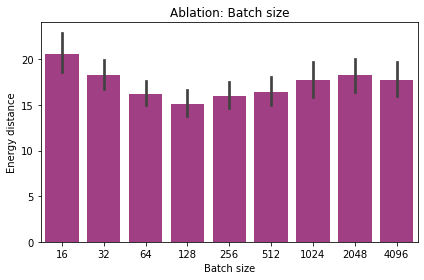

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

df_bs = dfs["batch_size"].copy()
df_bs["ablation_value"] = pd.to_numeric(df_bs["ablation_value"])
df_bs["ood_e_distance"] = pd.to_numeric(df_bs["ood_e_distance"])
df_bs = df_bs.sort_values("ablation_value")

fig, ax = plt.subplots()
sns.barplot(
    data=df_bs,
    x="ablation_value",
    y="ood_e_distance",
    color="#B12F8C",
    ax=ax,
)

ax.set_xlabel("Batch size")
ax.set_ylabel("Energy distance")
ax.set_title("Ablation: Batch size")
plt.tight_layout()
plt.show()
fig.savefig(os.path.join(output_dir, "ablation_bs_e_dist.pdf"), bbox_inches="tight")

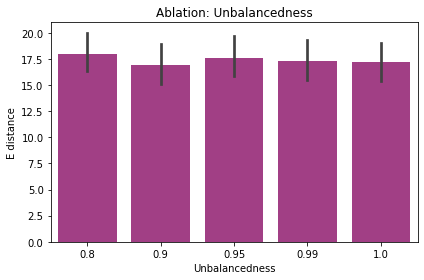

In [46]:
df_unb = dfs["unbalancedness"].copy()
df_unb["ablation_value"] = pd.to_numeric(df_unb["ablation_value"])
df_unb["ood_e_distance"] = pd.to_numeric(df_unb["ood_e_distance"])
df_unb = df_unb.sort_values("ablation_value")

fig, ax = plt.subplots()
sns.barplot(
    data=df_unb,
    x="ablation_value",
    y="ood_e_distance",
    color="#B12F8C",
    ax=ax,
)

ax.set_xlabel("Unbalancedness")
ax.set_ylabel("E distance")
ax.set_title("Ablation: Unbalancedness")
plt.tight_layout()
plt.show()
fig.savefig(os.path.join(output_dir, "ablation_unbalancedness_e_dist.pdf"), bbox_inches="tight")